# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


## Project: passive web payload classification
Student: **DaudHidayatRamadhan**. Dataset: AlexTrinity SQLi XSS, version 2; publisher-declared Apache 2.0, attribution and license stored with the raw file. The selected four-class file has 206,636 rows. Its labels are benchmark annotations and the publisher warns of incorrect/unfinished content. No payload is executed.

Target: Normal / SQLInjection / XSS / CommandInjection. Keep case and punctuation. Remove empty/invalid-label records, contradictory-payload groups and exact duplicates before a deterministic stratified split. Use a 24,000-row bounded subset fixed before evaluating any model. TF-IDF is fitted later inside the training/CV pipeline; processed text and targets are the train-ready representation.

Limits: near-duplicates and distribution/label-quality shifts are not eliminated. Accuracy on this benchmark does not demonstrate production attack detection.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
from pathlib import Path
import gzip, hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
if ROOT.name == "preprocessing":
    ROOT = ROOT.parent
RAW = ROOT / "sqli_xss_raw/payloads-v2.csv.gz"
OUTPUT = ROOT / "preprocessing/sqli_xss_preprocessing"
LABELS = ["SQLInjection", "XSS", "CommandInjection", "Normal"]
SEED = 42
SAMPLE_SIZE = 24000


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
raw_bytes = gzip.decompress(RAW.read_bytes())
raw_hash = hashlib.sha256(raw_bytes).hexdigest()
assert raw_hash == "e221ea9e118cdac6d7dabf085a224f42b6cde800a71c446f71c2dec609a2c233"
df = pd.read_csv(RAW)
assert list(df.columns) == ["Sentence"] + LABELS
print({"rows": len(df), "columns": list(df.columns), "raw_sha256": raw_hash})
# Show schema and label fields without rendering executable-looking payload strings.
display(df[LABELS].head())
display(df.dtypes.astype(str).rename("dtype").to_frame())


{'rows': 206636, 'columns': ['Sentence', 'SQLInjection', 'XSS', 'CommandInjection', 'Normal'], 'raw_sha256': 'e221ea9e118cdac6d7dabf085a224f42b6cde800a71c446f71c2dec609a2c233'}


,SQLInjection,XSS,CommandInjection,Normal
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0


,dtype
Sentence,object
SQLInjection,float64
XSS,float64
CommandInjection,float64
Normal,float64


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Missing values:


,count
Sentence,0
SQLInjection,0
XSS,0
CommandInjection,0
Normal,0


,payload characters
count,206636.000000
mean,453.911182
std,541.480620
min,1.000000
50%,315.000000
90%,926.000000
95%,1184.000000
99%,2627.650000
max,17263.000000


Duplicate payload rows: 6839


Empty/whitespace payload rows: 616
Non-one-hot label rows: 0


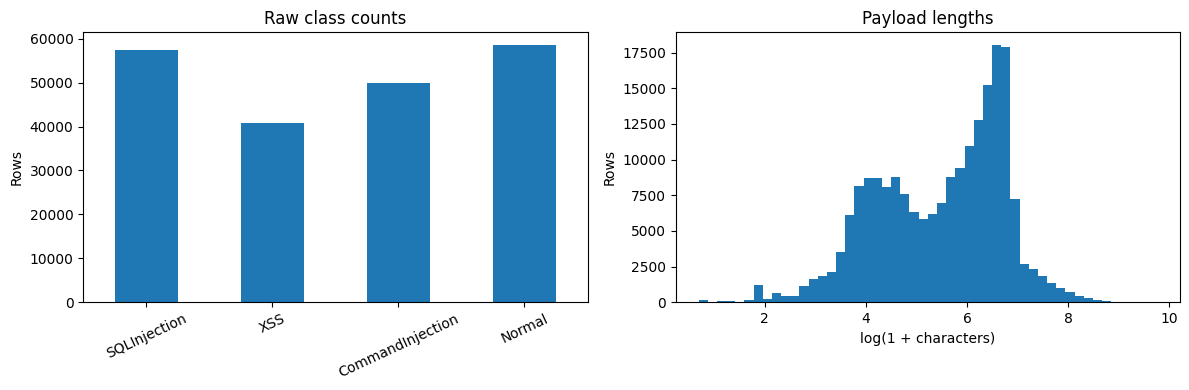

In [3]:
print("Missing values:")
display(df.isna().sum().rename("count").to_frame())
valid_text = df.Sentence.fillna("").astype(str)
lengths = valid_text.str.len()
display(lengths.describe(percentiles=[.5, .9, .95, .99]).to_frame("payload characters"))
print("Duplicate payload rows:", int(valid_text.duplicated().sum()))
print("Empty/whitespace payload rows:", int(valid_text.str.strip().eq("").sum()))
print("Non-one-hot label rows:", int((~df[LABELS].isin([0, 1]).all(axis=1) | df[LABELS].sum(axis=1).ne(1)).sum()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[LABELS].sum().plot.bar(ax=axes[0], title="Raw class counts")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=25)
axes[1].hist(np.log1p(lengths), bins=50)
axes[1].set(title="Payload lengths", xlabel="log(1 + characters)", ylabel="Rows")
plt.tight_layout()
plt.show()


### EDA interpretation and preprocessing rationale

Inspect the executed counts below: missing/empty inputs require removal, class imbalance calls for stratification and macro-F1, and duplicates/conflicting annotations must be handled before splitting. The heavy-tailed length distribution motivates bounded sparse features rather than deleting meaningful punctuation. Numerical scaling/one-hot encoding/binning are not appropriate for raw payload strings. No learned transformer is fitted on the held-out set. The fixed sample cap controls runtime, not model-score selection.


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Manual preprocessing, implemented before the automation script.
work = df.copy()
valid = work.Sentence.notna() & work.Sentence.fillna("").str.strip().ne("")
valid &= work[LABELS].isin([0, 1]).all(axis=1) & work[LABELS].sum(axis=1).eq(1)
work = work.loc[valid].copy()
work["target"] = work[LABELS].idxmax(axis=1)
label_counts = work.groupby("Sentence").target.nunique()
conflicts = set(label_counts[label_counts > 1].index)
conflict_rows = int(work.Sentence.isin(conflicts).sum())
work = work.loc[~work.Sentence.isin(conflicts)].drop_duplicates("Sentence").copy()
work["sample_id"] = work.Sentence.map(lambda text: hashlib.sha256(text.encode("utf-8")).hexdigest())
work = work.sort_values("sample_id").reset_index(drop=True)
clean = work[["sample_id", "Sentence", "target"]]
selected, excluded = train_test_split(clean, train_size=SAMPLE_SIZE, stratify=clean.target, random_state=SEED)
train, test = train_test_split(selected, test_size=0.2, stratify=selected.target, random_state=SEED)
train = train.sort_values("sample_id").reset_index(drop=True)
test = test.sort_values("sample_id").reset_index(drop=True)
assert set(train.sample_id).isdisjoint(test.sample_id)
assert train.target.nunique() == test.target.nunique() == 4
assert len(train) == 19200 and len(test) == 4800
assert train.Sentence.str.strip().ne("").all() and test.Sentence.str.strip().ne("").all()
OUTPUT.mkdir(parents=True, exist_ok=True)
file_hashes = {}
for split_name, frame in [("train", train), ("test", test)]:
    content = frame.to_csv(index=False, lineterminator="\n").encode("utf-8")
    destination = OUTPUT / f"{split_name}.csv.gz"
    with destination.open("wb") as handle:
        with gzip.GzipFile(fileobj=handle, filename="", mode="wb", mtime=0) as compressed:
            compressed.write(content)
    file_hashes[destination.name] = hashlib.sha256(destination.read_bytes()).hexdigest()
manifest = {
    "policy_version": 1, "seed": SEED, "sample_size": SAMPLE_SIZE,
    "raw_sha256": raw_hash, "raw_rows": len(df),
    "invalid_or_empty_rows": int((~valid).sum()),
    "conflicting_groups": len(conflicts), "conflicting_rows": conflict_rows,
    "clean_unique_rows": len(clean),
    "clean_class_counts": clean.target.value_counts().sort_index().to_dict(),
    "subset_excluded_rows": len(excluded),
    "train_rows": len(train), "test_rows": len(test),
    "train_class_counts": train.target.value_counts().sort_index().to_dict(),
    "test_class_counts": test.target.value_counts().sort_index().to_dict(),
    "files": file_hashes,
    "feature_boundary": "clean text+target; fit TF-IDF only on each training/CV fold",
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
print(json.dumps(manifest, indent=2))


{
  "policy_version": 1,
  "seed": 42,
  "sample_size": 24000,
  "raw_sha256": "e221ea9e118cdac6d7dabf085a224f42b6cde800a71c446f71c2dec609a2c233",
  "raw_rows": 206636,
  "invalid_or_empty_rows": 616,
  "conflicting_groups": 3,
  "conflicting_rows": 8,
  "clean_unique_rows": 199790,
  "clean_class_counts": {
    "CommandInjection": 48014,
    "Normal": 53750,
    "SQLInjection": 57278,
    "XSS": 40748
  },
  "subset_excluded_rows": 175790,
  "train_rows": 19200,
  "test_rows": 4800,
  "train_class_counts": {
    "CommandInjection": 4614,
    "Normal": 5166,
    "SQLInjection": 5504,
    "XSS": 3916
  },
  "test_class_counts": {
    "CommandInjection": 1154,
    "Normal": 1291,
    "SQLInjection": 1376,
    "XSS": 979
  },
  "files": {
    "train.csv.gz": "205952a704438c280a9f775a5d4bb7f97b92893bea65d141441b132c91f71139",
    "test.csv.gz": "8275add91319c49979bbc7cc4f6b931b73127054ba3b1ab204759cd5335f9ad6"
  },
  "feature_boundary": "clean text+target; fit TF-IDF only on each training/